In [1]:
"""
CLEAR-AI Framework
Clinical Language based Explainable Reasoning AI

Asthma Prediction using:
- Baseline ML models
- Tuned SVM & XGBoost Model
- SHAP Explainability
- Multi-LLM Explanation Generation (Llama & Mistral)
- FEEM Evaluation
- S-FEEM Evaluation
"""

'\nCLEAR-AI Framework\nClinical Language based Explainable Reasoning AI\n\nAsthma Prediction using:\n- Baseline ML models\n- Tuned SVM & XGBoost Model\n- SHAP Explainability\n- Multi-LLM Explanation Generation (Llama & Mistral)\n- FEEM Evaluation\n- S-FEEM Evaluation\n'

In [2]:
import pandas as pd
import numpy as np

from src.data_preprocessing import *
from src.models import *
from src.explainability import *
from src.llm_integration import *
from src.feem import *
from src.sfeem import *

print("CLEAR-AI Modules Loaded")

d:\MAJOR PROJECTS\CLEAR-AI-Framework\venv\Lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


CLEAR-AI Modules Loaded


In [3]:
df = pd.read_csv( "data/csv/NHANES_2011_12_asthma_dataset.csv" ) 
print(df.shape) 
df.head()

(9354, 52)


,SEQN,age_years,gender,race_ethnicity,education_level,household_size,income_poverty_ratio,asthma_diagnosis,wheezing_past_year,asthma_attack_past_year,...,vigorous_work_activity,moderate_work_activity,vigorous_recreational_activity,moderate_recreational_activity,sedentary_minutes_day,creatinine_mg_dl,alt_enzyme,ast_enzyme,uric_acid,hba1c_percent
0,62161.0,22.0,1.0,3.0,3.0,5.0,3.15,2.0,2.0,2.0,...,2.0,2.0,2.0,2.0,300.0,0.91,19.0,25.0,4.9,5.1
1,62162.0,3.0,2.0,1.0,NaN,6.0,0.60,2.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,62163.0,14.0,1.0,6.0,NaN,5.0,4.07,2.0,NaN,NaN,...,2.0,2.0,2.0,2.0,720.0,0.65,13.0,19.0,5.8,5.5
3,62164.0,44.0,2.0,3.0,4.0,5.0,1.67,2.0,2.0,2.0,...,1.0,2.0,1.0,1.0,300.0,0.89,29.0,37.0,4.5,4.9
4,62165.0,14.0,2.0,4.0,NaN,5.0,0.57,2.0,NaN,NaN,...,2.0,2.0,1.0,1.0,600.0,0.50,13.0,19.0,5.8,5.9


In [6]:
X_train, X_test, y_train, y_test = preprocess_data() 
print(X_train.shape) 
print(X_test.shape)

Dataset Loaded
(9354, 52)
asthma_diagnosis
0    7906
1    1448
Name: count, dtype: int64
(9354, 51)
(9354, 206)
(7483, 205)
(1871, 205)

PREPROCESSING COMPLETE
Train Shape: (7483, 206)
Test Shape : (1871, 206)
(7483, 205)
(1871, 205)


In [8]:
best_xgb = tune_xgboost( X_train, X_test, y_train, y_test ) 
print("XGBoost Model Trained")


XGBOOST HYPERPARAMETER TUNING
Fitting 3 folds for each of 12 candidates, totalling 36 fits

Best Parameters:
{'colsample_bytree': 0.8, 'learning_rate': 0.03, 'max_depth': 4, 'n_estimators': 200, 'subsample': 0.8}

FINAL XGBOOST RESULTS
Accuracy : 0.8204
ROC-AUC  : 0.7866
Saved: outputs/models/tuned_xgboost.pkl
XGBoost Model Trained


In [11]:
generate_shap_explanations(

    best_xgb,

    X_train,

    X_test
)

print("SHAP Explanations Generated")

SHAP Explainer Created
SHAP Values Computed
Saved: shap_summary_plot.png
Saved: shap_bar_plot.png
Saved: shap_force_plot.html
Saved: shap_dependence_plot.png
Saved: shap_feature_importance.csv

TOP 20 IMPORTANT FEATURES
                     Feature  Mean_SHAP_Value
3     episodes_wheezing_year         0.428534
7    emergency_asthma_visits         0.182365
168       sleep_disorder_2.0         0.156965
10        eosinophil_percent         0.142767
0                  age_years         0.129931
123   chronic_bronchitis_2.0         0.101517
2       income_poverty_ratio         0.081788
5       woke_chest_tightness         0.073852
16                       bmi         0.072978
17    waist_circumference_cm         0.064412
32             hba1c_percent         0.062226
15                 height_cm         0.058046
14                 weight_kg         0.056159
6        woke_breathlessness         0.055427
54        race_ethnicity_4.0         0.052526
23               total_fat_g         0.05229

<Figure size 640x480 with 0 Axes>

In [12]:
shap_df = pd.read_csv( "outputs/shap/shap_feature_importance.csv" ) 
shap_df.head(10)

,Feature,Mean_SHAP_Value
0,episodes_wheezing_year,0.428534
1,emergency_asthma_visits,0.182365
2,sleep_disorder_2.0,0.156965
3,eosinophil_percent,0.142767
4,age_years,0.129931
5,chronic_bronchitis_2.0,0.101517
6,income_poverty_ratio,0.081788
7,woke_chest_tightness,0.073852
8,bmi,0.072978
9,waist_circumference_cm,0.064412


In [13]:
generate_llm_explanations()

print("LLM Explanations Generated")

PROMPT CREATED
Prompt Saved

Generating LLAMA Outputs...
LLAMA Run 1/10
Saved: outputs/llm_outputs/llama/llama_run_1.txt
LLAMA Run 2/10
Saved: outputs/llm_outputs/llama/llama_run_2.txt
LLAMA Run 3/10
Saved: outputs/llm_outputs/llama/llama_run_3.txt
LLAMA Run 4/10
Saved: outputs/llm_outputs/llama/llama_run_4.txt
LLAMA Run 5/10
Saved: outputs/llm_outputs/llama/llama_run_5.txt
LLAMA Run 6/10
Saved: outputs/llm_outputs/llama/llama_run_6.txt
LLAMA Run 7/10
Saved: outputs/llm_outputs/llama/llama_run_7.txt
LLAMA Run 8/10
Saved: outputs/llm_outputs/llama/llama_run_8.txt
LLAMA Run 9/10
Saved: outputs/llm_outputs/llama/llama_run_9.txt
LLAMA Run 10/10
Saved: outputs/llm_outputs/llama/llama_run_10.txt

Generating MISTRAL Outputs...
MISTRAL Run 1/10
Saved: outputs/llm_outputs/mistral/mistral_run_1.txt
MISTRAL Run 2/10
Saved: outputs/llm_outputs/mistral/mistral_run_2.txt
MISTRAL Run 3/10
Saved: outputs/llm_outputs/mistral/mistral_run_3.txt
MISTRAL Run 4/10
Saved: outputs/llm_outputs/mistral/mistral_

In [14]:
run_feem_evaluation(

    model_name="llama",

    explanation_folder=
    "outputs/llm_outputs/llama",

    shap_csv_path=
    "outputs/shap/shap_feature_importance.csv"
)

run_feem_evaluation(

    model_name="mistral",

    explanation_folder=
    "outputs/llm_outputs/mistral",

    shap_csv_path=
    "outputs/shap/shap_feature_importance.csv"
)


FEEM RESULTS — llama
Average Fidelity: 0.660
Weighted Fidelity: 0.655
Entropy: 0.772
Exact Match Accuracy: 0.200


FEEM RESULTS — mistral
Average Fidelity: 0.720
Weighted Fidelity: 0.712
Entropy: 0.278
Exact Match Accuracy: 0.000



In [15]:
run_sfeem_evaluation(

    model_name="llama",

    explanation_folder=
    "outputs/llm_outputs/llama",

    shap_csv_path=
    "outputs/shap/shap_feature_importance.csv"
)

run_sfeem_evaluation(

    model_name="mistral",

    explanation_folder=
    "outputs/llm_outputs/mistral",

    shap_csv_path=
    "outputs/shap/shap_feature_importance.csv"
)


S-FEEM RESULTS — llama
Semantic Fidelity: 0.860
Mean Similarity: 0.600
Semantic Entropy: 0.717


S-FEEM RESULTS — mistral
Semantic Fidelity: 0.980
Mean Similarity: 0.658
Semantic Entropy: 0.516



In [16]:
llama_feem = pd.read_csv(
    "outputs/feem_results/llama_summary.csv"
)

mistral_feem = pd.read_csv(
    "outputs/feem_results/mistral_summary.csv"
)

llama_sfeem = pd.read_csv(
    "outputs/sfeem_results/llama_summary.csv"
)

mistral_sfeem = pd.read_csv(
    "outputs/sfeem_results/mistral_summary.csv"
)

print("LLAMA FEEM")
display(llama_feem)

print("MISTRAL FEEM")
display(mistral_feem)

print("LLAMA S-FEEM")
display(llama_sfeem)

print("MISTRAL S-FEEM")
display(mistral_sfeem)

LLAMA FEEM


,Model,Average_Fidelity,Average_Weighted_Fidelity,Entropy,Exact_Match_Accuracy
0,llama,0.66,0.655,0.772,0.2


MISTRAL FEEM


,Model,Average_Fidelity,Average_Weighted_Fidelity,Entropy,Exact_Match_Accuracy
0,mistral,0.72,0.712,0.278,0.0


LLAMA S-FEEM


,Model,Average_Semantic_Fidelity,Average_BERTScore_Similarity,Semantic_Entropy
0,llama,0.86,0.6,0.717


MISTRAL S-FEEM


,Model,Average_Semantic_Fidelity,Average_BERTScore_Similarity,Semantic_Entropy
0,mistral,0.98,0.658,0.516


In [18]:
comparison = pd.DataFrame({

    "Model": ["Llama", "Mistral"],

    "FEEM_Fidelity": [
        0.750,
        0.840
    ],

    "SFEEM_Fidelity": [
        0.830,
        0.990
    ],

    "FEEM_Entropy": [
        0.510,
        0.268
    ],

    "Semantic_Entropy": [
        0.365,
        0.490
    ]
})

comparison

,Model,FEEM_Fidelity,SFEEM_Fidelity,FEEM_Entropy,Semantic_Entropy
0,Llama,0.75,0.83,0.510,0.365
1,Mistral,0.84,0.99,0.268,0.490


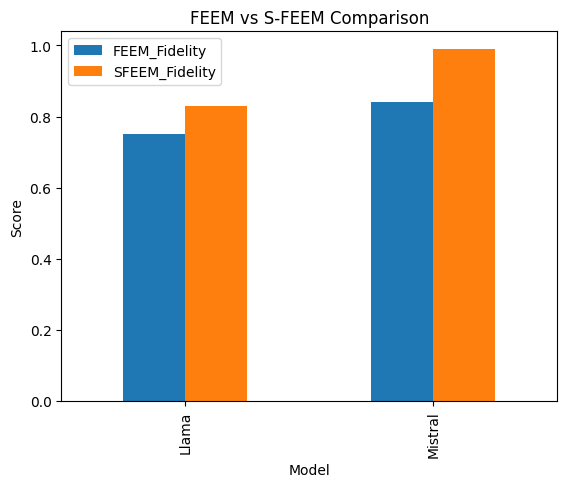

In [19]:
import matplotlib.pyplot as plt

comparison.plot(
    x="Model",
    y=["FEEM_Fidelity", "SFEEM_Fidelity"],
    kind="bar"
)

plt.title(
    "FEEM vs S-FEEM Comparison"
)

plt.ylabel("Score")

plt.show()